# Prevención de Fraude — Mercado Libre

**Objetivo General:** predecir si una transacción es fraudulenta para *maximizar la ganancia*, donde por cada transacción legítima aprobada se gana el **25%** del monto; mientras que cada fraude aprobado representa una pérdida del **100%** del monto.

## Análisis Exploratorio de Datos (EDA)

En esta sección se realizará la exploración y el entendimiento de los datos. Adicionalmente, se validan las hipótesis iniciales dentro las que se incluyen:
1. Se cumple que los casos de fraude son una fracción pequeña de las transacciones? Qué porcentaje representan?
2. El comportamiento de los datos indica que montos atípics se asocian a mayor fraude?
3. Los casos fraudulentos siguen algún patrón relacionado a las horas del día?
4. Suele ocurrir que las entidades nuevas o anómalas son más riesgosas?
5. Suelen haber más casos fraudulento según el país de la transacción?


### Configuración y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_style("white")

In [2]:
TARGET = "fraude"
df = pd.read_csv("../data/fraud_meli_dataset.csv", parse_dates=["fecha"])
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (150000, 19)


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0


### Estructura general

De los datos cargados, se puede notar que las variables vienen anonimizadas (`a`–`p`). Adicionalmente, se tienen 4 campos que si se conocen, que son:
- `fecha`
- `monto` - importe de la transacción.
- `score` - un score de riesgo preexistente.
- `fraude` - variable objetivo.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   a       150000 non-null  int64         
 1   b       137016 non-null  float64       
 2   c       137016 non-null  float64       
 3   d       149635 non-null  float64       
 4   e       150000 non-null  float64       
 5   f       149989 non-null  float64       
 6   g       149806 non-null  str           
 7   h       150000 non-null  int64         
 8   j       150000 non-null  str           
 9   k       150000 non-null  float64       
 10  l       149989 non-null  float64       
 11  m       149635 non-null  float64       
 12  n       150000 non-null  int64         
 13  o       41143 non-null   str           
 14  p       150000 non-null  str           
 15  fecha   150000 non-null  datetime64[us]
 16  monto   150000 non-null  float64       
 17  score   150000 non-null  int64         


### Calidad de datos
Se hace un análisis para verificar las variables con nulos, duplicados y la cardinalidad de cada una.

In [4]:
nulos = df.isna().sum()
calidad = pd.DataFrame({
    "n_nulos": nulos,
    "%_nulos": (nulos / len(df) * 100).round(2),
    "n_unicos": df.nunique(),
    "dtype": df.dtypes.astype(str),
})
print("Filas duplicadas:", df.duplicated().sum())
calidad.sort_values("%_nulos", ascending=False)

Filas duplicadas: 0


,n_nulos,%_nulos,n_unicos,dtype
o,108857,72.57,2,str
c,12984,8.66,135090,float64
b,12984,8.66,7672,float64
d,365,0.24,51,float64
m,365,0.24,1793,float64
g,194,0.13,51,str
f,11,0.01,1338,float64
l,11,0.01,7297,float64
a,0,0.00,4,int64
score,0,0.00,101,int64


**Análisis:**
- Dado que `k` tiene un valor único por fila (150.000) se puede asociar con un identificador. Por lo tanto, no es una variable que aporte mucho para el entrenamiento general del modelo y puede analizarse si vale la pena descartarla.
- `o` falta en ~73% de los casos.
- `b`/`c` (~8.7%) y `d`/`m` (~0.24%) comparten patrón de ausencia.
- Sin filas duplicadas exactas.

#### Análisis de columnas con datos nulos

In [5]:
cols_con_nulos = [c for c in df.columns if df[c].isna().any()]
rows = []
base = df[TARGET].mean()
for col in cols_con_nulos:
    rows.append({
        "columna": col,
        "tasa_fraude_null": df.loc[df[col].isna(), TARGET].mean(),
        "tasa_fraude_no_null": df.loc[df[col].notna(), TARGET].mean(),
    })
print(f"Tasa de fraude global: {base:.4f}")
pd.DataFrame(rows).round(4)

Tasa de fraude global: 0.0500


,columna,tasa_fraude_null,tasa_fraude_no_null
0,b,0.0638,0.0487
1,c,0.0638,0.0487
2,d,0.0795,0.0499
3,f,0.0000,0.0500
4,g,0.0773,0.0500
5,l,0.0000,0.0500
6,m,0.0795,0.0499
7,o,0.0205,0.1279


**Análisis:** la tasa de fraude difiere fuertemente según la presencia de `o`, pues alcanza ~12.8% en los registros donde la variable está presente (no nula), frente a solo ~2.0% en los registros donde está ausente (nula). Es decir, la ausencia de `o` es informativa, por lo que conviene conservarla mediante un **indicador de ausencia** (`*_is_null`) en el feature engineering.

### Proporciones de la variable objetivo

,conteo,proporcion
fraude,,
0,142500,0.95
1,7500,0.05


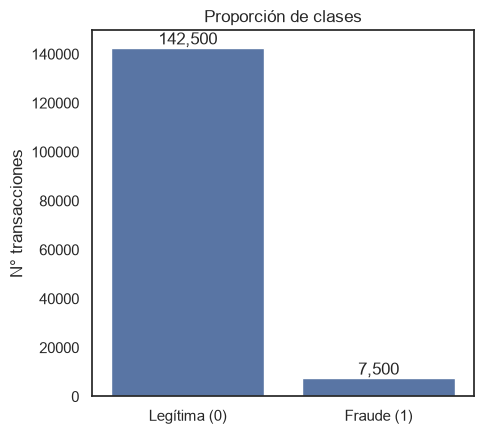

In [6]:
conteo = df[TARGET].value_counts()
prop = df[TARGET].value_counts(normalize=True)
display(pd.DataFrame({"conteo": conteo, "proporcion": prop.round(4)}))

# Distribution plot
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.barplot(x=conteo.index, y=conteo.values, ax=ax)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Legítima (0)", "Fraude (1)"])
ax.set_ylabel("N° transacciones"); ax.set_xlabel("")
ax.set_title(f"Proporción de clases")

for i, v in enumerate(conteo.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

**Anális:** Los resultados anteriores permiten confirmar la ***Hipótesis 1***, dado que los casos de fraude representan el **5%** (7.500 de 150.000).

### Análisis variables númericas
Se mide la relación e impacto de las diferentes variables númericas con la variable objetivo `fraud`.

#### Variable score de riesgo

,mean,50%
fraude,,
0,46.92,47.0
1,69.90,85.0



Tasa de fraude por rango de score:
              mean  count
_score_bin               
(-1, 25]    0.0381  41268
(25, 50]    0.0057  37524
(50, 75]    0.0263  37538
(75, 100]   0.1404  33670


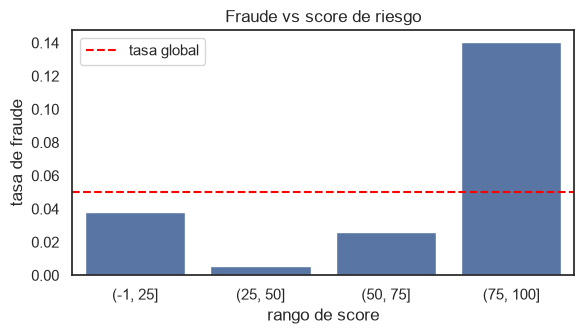

In [7]:
display(df.groupby(TARGET)["score"].describe()[["mean", "50%"]].round(2))

df["_score_bin"] = pd.cut(df["score"], bins=[-1, 25, 50, 75, 100])
tasa = df.groupby("_score_bin", observed=True)[TARGET].agg(["mean", "count"])
print("\nTasa de fraude por rango de score:")
print(tasa.round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=tasa.index.astype(str), y=tasa["mean"], ax=ax)
ax.axhline(df[TARGET].mean(), color="red", ls="--", label="tasa global")
ax.set_ylabel("tasa de fraude"); ax.set_xlabel("rango de score")
ax.set_title("Fraude vs score de riesgo"); ax.legend()
plt.tight_layout(); plt.show()
df.drop(columns="_score_bin", inplace=True)

**Análisis:** De estos resultados se puede notar que `score` es una señal bastante fuerte. El gráfico muestra que en el rango alto (75–100) la tasa de fraude sube a ~14%. Adicionalmente, se puede notar que la relación no es monótona, pues vemos que en el rango 25–50 tiene la tasa más baja.

*Nota:* Un detalle que se puede confirmar es si esta variable se tiene disponible en el momento de hacer predicciones en producción, para saber si se podría tener en cuenta o no en la etapa de entrenamiento.

#### Distribución del Monto

,mean,50%,75%,max
fraude,,,,
0,41.97,20.18,40.02,3696.35
1,72.97,25.87,59.06,3424.81


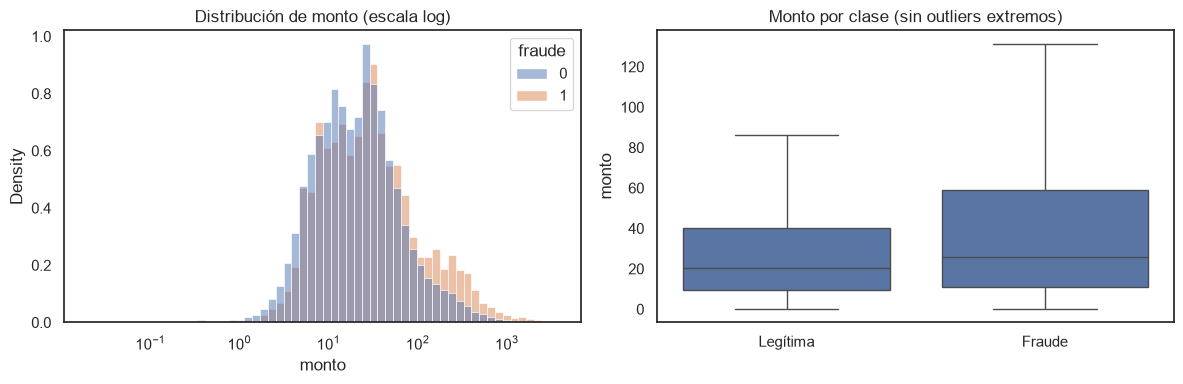

In [8]:
display(df.groupby(TARGET)["monto"].describe()[["mean", "50%", "75%", "max"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="monto", hue=TARGET, bins=60, stat="density",
             common_norm=False, log_scale=True, ax=axes[0])
axes[0].set_title("Distribución de monto (escala log)")

sns.boxplot(data=df, x=TARGET, y="monto", showfliers=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Legítima", "Fraude"]); axes[1].set_xlabel("")
axes[1].set_title("Monto por clase (sin outliers extremos)")
plt.tight_layout(); plt.show()

**Análisis:** Las gráficas evidencian que el monto medio del fraude es mayor (~73 vs ~42) y la cola derecha es más pesada, indicando que el fraude tiene mayor densidad en montos altos. Sin embargo, dado que sus **medianas son cercanas** y no muestran una distinción tan clara en su comportamiento, se puede concluir que el monto aporta señal pero no es tan fuerte.

#### Otras variables númericas
Se mide la correlación lineal entre las diferentes variables númericas y la variable objetivo `fraud`.

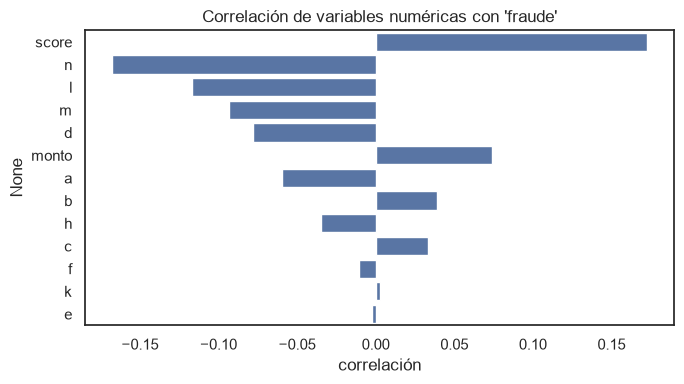

,Correlación con Fraude
score,0.173
n,-0.168
l,-0.117
m,-0.093
d,-0.078
monto,0.074
a,-0.060
b,0.039
h,-0.035
c,0.033


In [9]:
num_cols = df.select_dtypes("number").columns.drop(TARGET)
corr = df[num_cols].corrwith(df[TARGET]).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=corr.values, y=corr.index, ax=ax)
ax.set_title("Correlación de variables numéricas con 'fraude'")
ax.set_xlabel("correlación")
plt.tight_layout(); plt.show()

display(pd.DataFrame(corr.round(3)).rename(columns={0: 'Correlación con Fraude'}))

**Análisis:** De los resultados anteriores se puede notar varios puntos:
1. Las variables numéricas más informativas son `score` (+0.17), `n` (−0.17), `l` (−0.12), `m` (−0.09) y `monto` (+0.07). 
2. La variable `k` que se intuía que era un ID, tiene una correlación de ~0. Por ende, se puede omitir esta variable.
3. Dado que las correlaciones son moderadas, pues ninguna variable resuelve el problema sola, se justifica probar modelos no lineales.

### Análisis variables categóricas y binarias
Se analiza el impacto de las variables categóricas y binarias en los casos fraudulentos.

#### Variable g
En primer lugar se analiza la variable g que hace referencia al país en el que se realizó la transacción. Básicamente, lo que revisa es la cantidad de países que tienen más de un umbral determinado de casos.

Total de países: 51
 min_casos  n_paises  %_transacciones
         1        51            99.87
         5        16            99.83
        10        13            99.81
        50         9            99.75
       100         6            99.62
       500         4            99.22
      1000         4            99.22


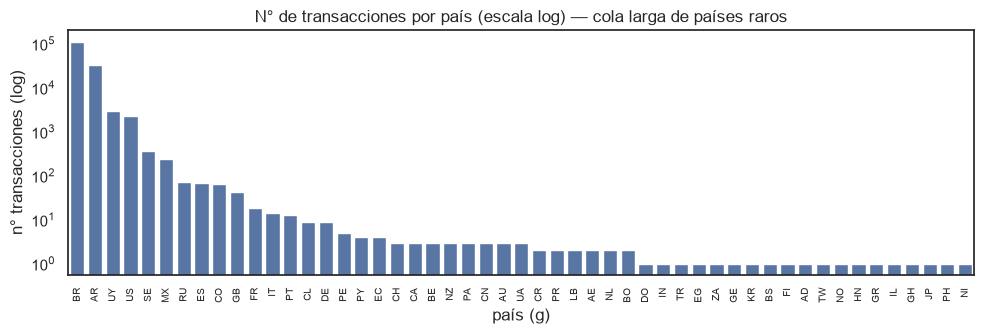

In [10]:
casos_por_pais = df["g"].value_counts()

umbrales = [1, 5, 10, 50, 100, 500, 1000]
cobertura = pd.DataFrame({
    "min_casos": umbrales,
    "n_paises": [(casos_por_pais >= u).sum() for u in umbrales],
    "%_transacciones": [round(casos_por_pais[casos_por_pais >= u].sum() / len(df) * 100, 2)
                        for u in umbrales],
})
print(f"Total de países: {df['g'].nunique()}")
print(cobertura.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.barplot(x=casos_por_pais.index, y=casos_por_pais.values, ax=ax)
ax.set_yscale("log")
ax.set_title("N° de transacciones por país (escala log) — cola larga de países raros")
ax.set_ylabel("n° transacciones (log)"); ax.set_xlabel("país (g)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout(); plt.show()

**Análisis:** De los ~51 países, solo 4 tienen más de 500 casos (BR, AR, US, UY) y entre ellos cubren casi el **99%** de las transacciones. El resto son países con muy pocos registros, por lo que se puede considerar que sus tasas de fraude son ruido estadístico. 
De esta manera, para la etapa de feature engineering puede ser conveniente **filtrar/agrupar** los países con pocos casos en una categoría `"OTROS"`.

      mean   count
g                 
BR  0.0552  111628
AR  0.0369   31964
US  0.0308    2273
UY  0.0098    2967


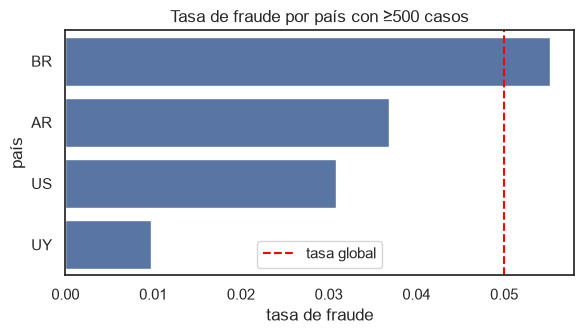

In [11]:
MIN_CASOS = 500
paises_validos = casos_por_pais[casos_por_pais >= MIN_CASOS].index
g_rate = (df[df["g"].isin(paises_validos)]
          .groupby("g")[TARGET].agg(["mean", "count"])
          .sort_values("mean", ascending=False))
print(g_rate.round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=g_rate["mean"], y=g_rate.index, ax=ax)
ax.axvline(df[TARGET].mean(), color="red", ls="--", label="tasa global")
ax.set_title(f"Tasa de fraude por país con ≥{MIN_CASOS} casos")
ax.set_xlabel("tasa de fraude"); ax.set_ylabel("país"); ax.legend()
plt.tight_layout(); plt.show()

**Análisis:** Entre los países con más de 500 casos (BR, AR, US, UY), Brasil es el que presenta la mayor tasa de fraude (~5.5%), apenas por encima de la media global (5%), mientras que Uruguay es el más bajo (~1%). Las diferencias existen (BR es ~5× UY), por lo que el país aporta señal moderada al modelo, aunque ninguno se aleja drásticamente de la tasa general.

#### Variable j
Se hace un análisis especifico para la variable j debido a que es una variable categórica con miles de categoría. Se revisa que influencia tiene esta variable sobre los casos fraudulentos

In [12]:
casos_por_cat = df["j"].value_counts()
print("Cardinalidad de j:", df["j"].nunique())
print(f"% de categorías con <=3 casos: {(casos_por_cat <= 3).mean() * 100:.1f}%")

Cardinalidad de j: 8324
% de categorías con <=3 casos: 49.3%


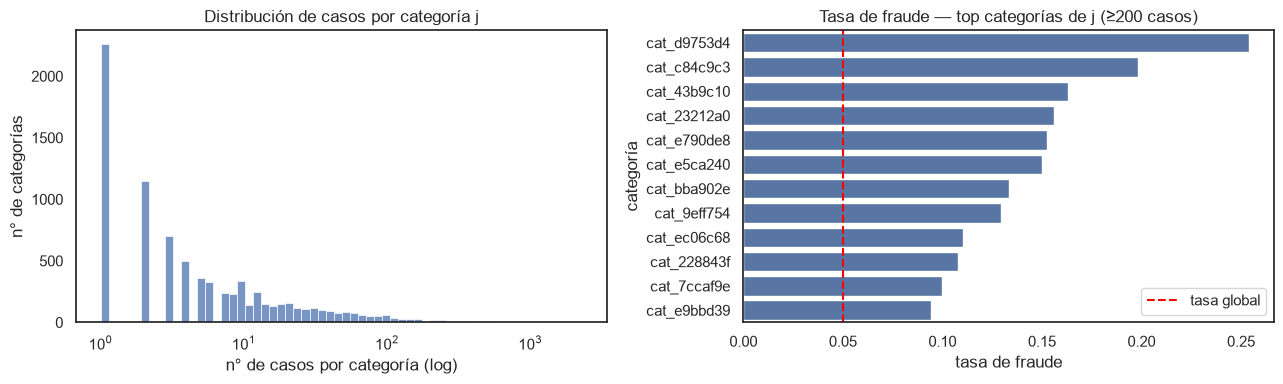

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Izq: la mayoría de las categorías tiene muy pocos casos (cola larga)
sns.histplot(casos_por_cat.values, bins=60, log_scale=(True, False), ax=axes[0])
axes[0].set_title("Distribución de casos por categoría j")
axes[0].set_xlabel("n° de casos por categoría (log)"); axes[0].set_ylabel("n° de categorías")

# Der: tasa de fraude de las categorías con soporte suficiente (>=200 casos)
top_j = (df.groupby("j")[TARGET].agg(["mean", "count"])
         .query("count >= 200").sort_values("mean", ascending=False).head(12))
sns.barplot(x=top_j["mean"], y=top_j.index, ax=axes[1])
axes[1].axvline(df[TARGET].mean(), color="red", ls="--", label="tasa global")
axes[1].set_title("Tasa de fraude — top categorías de j (≥200 casos)")
axes[1].set_xlabel("tasa de fraude"); axes[1].set_ylabel("categoría"); axes[1].legend()
plt.tight_layout(); plt.show()

**Análisis:** De los resultados anteriores se puede notar que la mitad de las categorías tiene <=3 casos. Adicionalmente, esto también se evidencia en el gráfico de la distribución donde la mayoría de las categorías se concentra entre $10^0$ y $10^1$ casos.

Por otra parte, entre las categorías con mayor frecuencia (más de 200 casos), se puede notar que muchas de ellas superan la tasa de fraude global. Por lo que `j` **no se descarta**, pero tampoco admite one-hot (8.300 columnas), pues es preferible optar por **frequency encoding o target encoding** en feature engineering.

#### Otras variables categóricas
Adicionalmente, se hace el análisis sobre las otras 4 variables categóricas restantes para entender su relación con los casos fraudulentos.

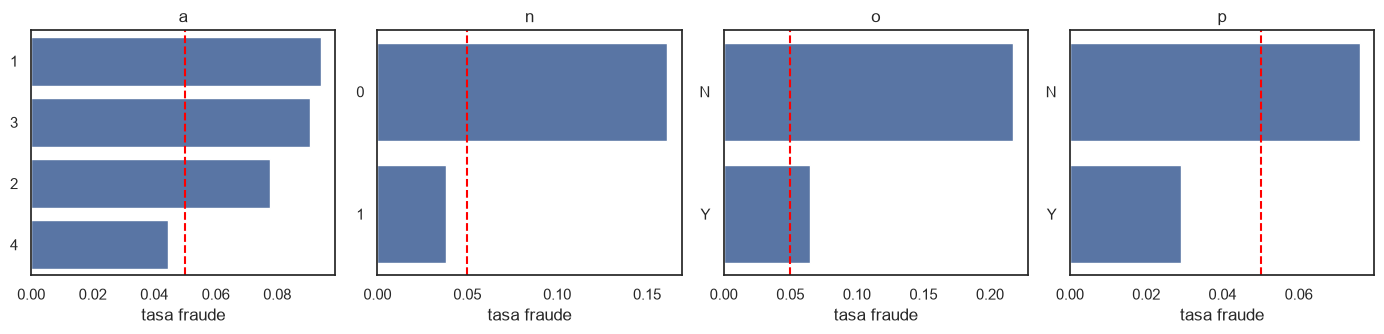

In [14]:
bin_cols = ["a", "n", "o", "p"]
fig, axes = plt.subplots(1, len(bin_cols), figsize=(14, 3.5))
for ax, c in zip(axes, bin_cols):
    t = df.groupby(c, observed=True)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=t.values, y=t.index.astype(str), ax=ax)
    ax.axvline(df[TARGET].mean(), color="red", ls="--")
    ax.set_title(c); ax.set_xlabel("tasa fraude"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Análisis:** De los resultados anteriores se puede notar que:
- `n` (0 → 16% vs 1 → 3.8%), `o` (N → 22% vs Y → 6.5%) y `p` (N → 7.6% vs Y → 2.9%) son binarias con fuerte poder discriminante.
- `a` (4 categorías): la categoría mayoritaria (4) tiene la menor tasa de fraude.

### Análisis variable temporal
En esta sección se analiza si existe algún patrón entre los casos de fraude detectados y el momento del día.

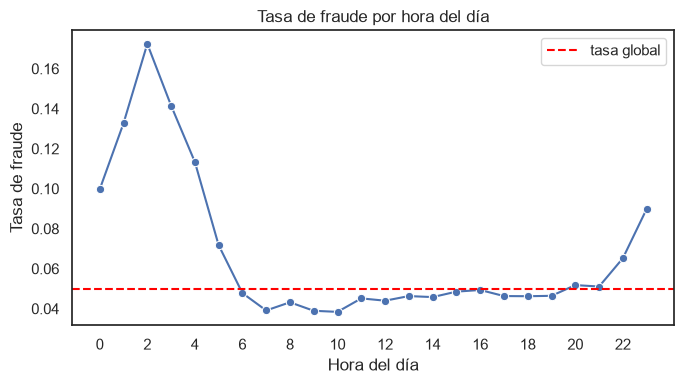

In [15]:
# Se obtiene la hora de la fecha
df["_hora"] = df["fecha"].dt.hour
tasa_hora = df.groupby("_hora")[TARGET].mean()

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(x=tasa_hora.index, y=tasa_hora.values, marker="o", ax=ax)
ax.axhline(df[TARGET].mean(), color="red", ls="--", label="tasa global")

ax.set_xlabel("Hora del día"); ax.set_ylabel("Tasa de fraude")
ax.set_title("Tasa de fraude por hora del día"); ax.set_xticks(range(0, 24, 2))
ax.legend(); plt.tight_layout(); plt.show()

df.drop(columns="_hora", inplace=True)

**Análisis:** La gráfica anterior muestra una fuerte señal entre el momento del día y los casos de fraude, evidenciando que el fraude se dispara en la **madrugada (1–4 AM: 11–17%)** frente a ~3.8% en horario diurno.

## Conclusiones

El EDA permitió entender la estructura, la calidad y el poder predictivo de las variables disponibles. A continuación se resume la validación de las hipótesis que se plantearon en un inicio.


**Validación de hipótesis:**

| Hipótesis | Resultado | Evidencia |
|---|---|---|
| H1 Desbalance | ✅ Confirmada | Caso de Fraude = 5% del total de observaciones |
| H2 Monto | ⚠️ Parcial | Media mayor en fraude (73 vs 42), pero medianas cercanas. Indica señal débil |
| H3 Temporal | ✅ Confirmada | Madrugada 1–4 AM: 11–17% vs ~3.8% diurno |
| H4 Comportamiento/identidad | ➖ No testeable | No hay ID de usuario/tarjeta; `k` es un identificador sin señal |
| H5 Geografía | ✅ Confirmada | País `g` (BR/AR/US/UY) y binarias `n`, `o`, `p` discriminan |


Se continua con la parte de feature engineering en el notebook `02_feature_engineering.ipynb`.